# Premier Card — EDA
Imports the reusable `PremierEDA` class + `add_features` from `src/eda.py`.
First load reads the xlsx (~28s) then pickle-caches; reruns are instant.

In [1]:
import sys, pathlib
p = pathlib.Path.cwd()
src = next((d / 'src' for d in [p, *p.parents] if (d / 'src' / 'eda.py').exists()), None)
sys.path.insert(0, str(src))
import pandas as pd
pd.set_option('display.width', 200, 'display.max_columns', 30)
%matplotlib inline
from eda import PremierEDA, add_features
from explain import show          # show(obj, "label") -> displays it + an LLM plain-English explanation
eda = PremierEDA()
eda.df.shape

(500000, 24)

In [2]:
eda.legend()    # f-code -> readable variable name -> description (run this first)
# tip: eda.renamed().head()  gives the data with readable column names

,variable,description
code,,
f1,revolve_bal,Avg Revolve Balance 12m
f2,cancel_calls,Cancellation Calls 12m
f3,collect_calls,Collection Cancel Calls
f4,rewards_bal,Rewards Points Balance
f5,total_spend,Total Spend 12m
f6,air_spend,Airlines Spend
f7,other_spend,Other Spend (refunds<0)
f8,ent_spend,Entertainment Spend
f9,lodge_spend,Lodging Spend


## 1. Overview — per-feature stats

In [3]:
show(eda.overview(), "per-feature stats: range, missing %, skew, % non-zero")

,code,name,missing%,min,max,mean,median,skew,nonzero%
variable,,,,,,,,,
revolve_bal,f1,Avg Revolve Balance 12m,0.0,0.00,17967.73,2467.31,0.00,2.23,46.8
cancel_calls,f2,Cancellation Calls 12m,0.0,0.00,1.00,0.17,0.00,1.72,17.4
collect_calls,f3,Collection Cancel Calls,0.0,0.00,1.00,0.11,0.00,2.52,10.9
rewards_bal,f4,Rewards Points Balance,51.4,2.00,697899.35,126607.13,50705.19,1.97,100.0
total_spend,f5,Total Spend 12m,1.3,0.00,13596.28,3464.81,2165.85,1.37,93.5
air_spend,f6,Airlines Spend,23.1,0.00,52198.43,10032.05,4022.77,1.83,85.4
other_spend,f7,Other Spend (refunds<0),23.1,-274.65,146700.55,30821.55,14396.27,1.69,99.8
ent_spend,f8,Entertainment Spend,23.1,0.00,9419.87,1522.99,303.99,2.03,68.8
lodge_spend,f9,Lodging Spend,23.1,0.00,10828.99,1651.74,264.75,2.13,63.5


**🧠 LLM:** - **Missing Data**: Several features, like `rewards_bal` and `rewards_redeemed`, have high missing percentages (51.4%), which could impact the accuracy of our profitability scoring. We need to consider how to handle these missing values effectively.

- **Skewness**: Features such as `revolve_bal` and `cancel_calls` show positive skew (46.8 and 1.72, respectively), indicating that most cardmembers have low values with a few high outliers. This could affect how we interpret profitability, as a few high balances might disproportionately influence the score.

- **Non-Zero Values**: Most features have a high percentage of non-zero values, particularly `total_spend` (93.5%) and `dine_spend` (90.4%). This suggests that these metrics are generally applicable across cardmembers and can be reliable indicators of profitability.

- **Range of Values**: The wide range in features like `rewards_bal` (from 2 to 697,899) indicates significant variability among cardmembers. This variability is crucial for distinguishing between high and low profitability in our scoring framework.

- **Mean vs. Median**: The mean and median values for features like `total_spend` (mean: 3464.81, median: 2165.85) show that the distribution is right-skewed. This difference suggests that we should be cautious in using the mean for scoring, as it may not represent the typical cardmember's spending behavior.

- **Feature Relevance**: Features with low skew and high non-zero percentages, such as `supp_accts` and `active_cards`, may provide more consistent insights into profitability and should be prioritized in our scoring model.

,code,name,missing%,min,max,mean,median,skew,nonzero%
variable,,,,,,,,,
revolve_bal,f1,Avg Revolve Balance 12m,0.0,0.00,17967.73,2467.31,0.00,2.23,46.8
cancel_calls,f2,Cancellation Calls 12m,0.0,0.00,1.00,0.17,0.00,1.72,17.4
collect_calls,f3,Collection Cancel Calls,0.0,0.00,1.00,0.11,0.00,2.52,10.9
rewards_bal,f4,Rewards Points Balance,51.4,2.00,697899.35,126607.13,50705.19,1.97,100.0
total_spend,f5,Total Spend 12m,1.3,0.00,13596.28,3464.81,2165.85,1.37,93.5
air_spend,f6,Airlines Spend,23.1,0.00,52198.43,10032.05,4022.77,1.83,85.4
other_spend,f7,Other Spend (refunds<0),23.1,-274.65,146700.55,30821.55,14396.27,1.69,99.8
ent_spend,f8,Entertainment Spend,23.1,0.00,9419.87,1522.99,303.99,2.03,68.8
lodge_spend,f9,Lodging Spend,23.1,0.00,10828.99,1651.74,264.75,2.13,63.5


## 2. Missingness — structured co-missing clusters (treat as signal, not impute)

In [4]:
show(eda.missingness(), "structured co-missing feature clusters (missing = signal, not noise)")

,cluster,missing%,interpretation
0,f23,87.8,Emails Clicked 6m
1,f18,61.9,Consumer Lend Line
2,f17,58.5,Total Lend Line
3,"f4, f21",51.4,"Rewards Points Balance, Rewards Redeemed 12m"
4,"f6, f7, f8, f9, f10",23.1,"Airlines Spend, Other Spend (refunds<0), Enter..."
5,f22,18.9,Emails Opened 6m
6,f12,5.0,Website Logins
7,"f13, f14, f15, f16",2.7,"Lounge Access Count, Airline Credits Used, Cab..."
8,f5,1.3,Total Spend 12m
9,f11,0.5,Avg Risk Score (PD-like)


**🧠 LLM:** - **High Missing Percentages Indicate Key Features**: Features like "Emails Clicked 6m" (87.8% missing) and "Consumer Lend Line" (61.9% missing) are critical for understanding customer behavior, suggesting that their absence is a strong signal of profitability.

- **Clustered Features Reveal Patterns**: The grouping of features (e.g., "Rewards Points Balance" and "Rewards Redeemed 12m") with a 51.4% missing rate indicates that customers who engage less with rewards may be less profitable, highlighting areas for targeted analysis.

- **Low Missing Percentages Suggest Stability**: Features with low missing rates, such as "Total Spend 12m" (1.3%) and "# Active Charge Cards" (0.0%), are likely reliable indicators of profitability, providing a stable foundation for our scoring framework.

- **Actionable Insights for Scoring**: Understanding which features are missing and their implications allows us to refine our profitability score, ensuring we prioritize the right signals that correlate with high-value customers.

- **Focus on High Missing Features**: By concentrating on features with high missing percentages, we can better identify and target the top 20% of cardmembers who are truly profitable, improving our scoring accuracy.

,cluster,missing%,interpretation
0,f23,87.8,Emails Clicked 6m
1,f18,61.9,Consumer Lend Line
2,f17,58.5,Total Lend Line
3,"f4, f21",51.4,"Rewards Points Balance, Rewards Redeemed 12m"
4,"f6, f7, f8, f9, f10",23.1,"Airlines Spend, Other Spend (refunds<0), Enter..."
5,f22,18.9,Emails Opened 6m
6,f12,5.0,Website Logins
7,"f13, f14, f15, f16",2.7,"Lounge Access Count, Airline Credits Used, Cab..."
8,f5,1.3,Total Spend 12m
9,f11,0.5,Avg Risk Score (PD-like)


**🧠 LLM:** - **High Missingness**: `email_click`, `consumer_lend`, and `lend_line` have over 80% missing data. This could impact their reliability in the scoring model.

- **Moderate Missingness**: Features like `rewards_redeemed`, `rewards_bal`, and `dine_spend` have around 40-60% missing data, which may still affect model accuracy.

- **Low Missingness**: Features such as `logins`, `cab_months`, and `air_credit` have less than 10% missing data, making them more reliable for analysis.

- **Impact on Model**: High missingness in key features might require imputation or exclusion to maintain model integrity.

- **Feature Selection**: Consider focusing on features with lower missingness for more robust predictions.

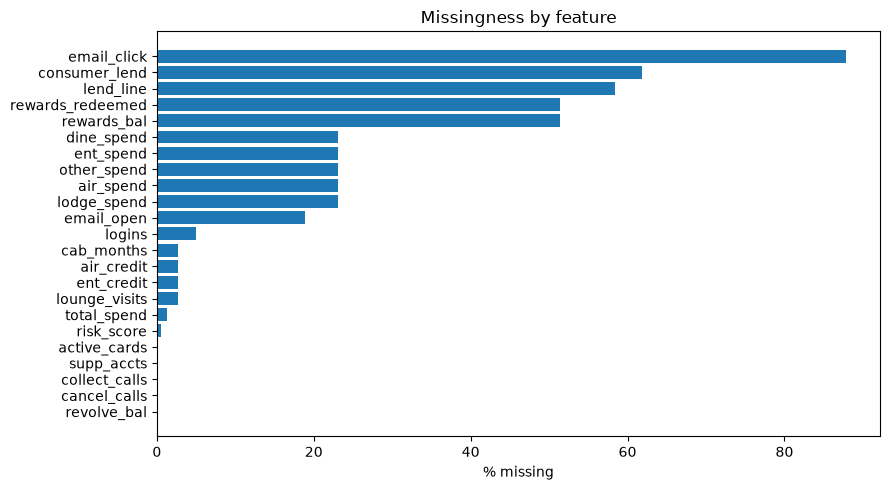

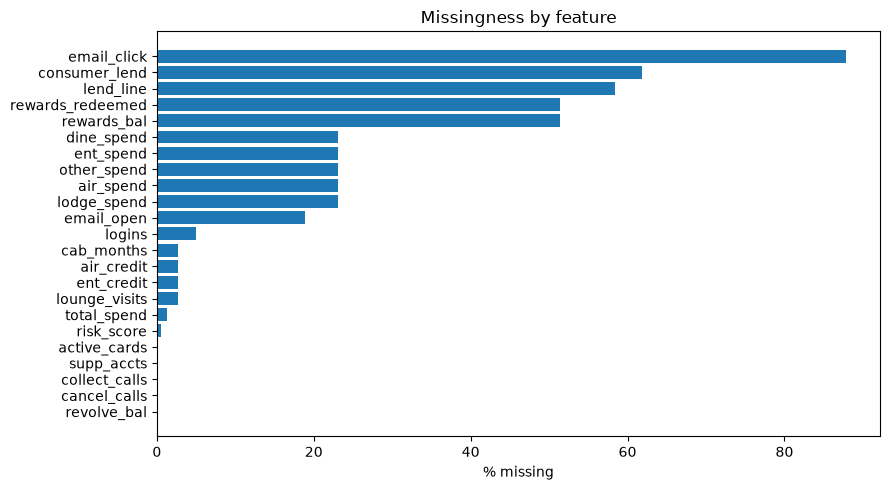

In [5]:
show(eda.plot_missingness(), "% missing per feature (bar chart)")

## 3. Correlations — ordered by overall correlation strength

In [6]:
show(eda.corr_order(), "features ranked by overall correlation strength + each one's strongest partner")

,code,variable,corr_strength,strongest_partner,strongest_r
0,f10,dine_spend,0.227,other_spend,0.70
1,f6,air_spend,0.224,lodge_spend,0.71
2,f8,ent_spend,0.203,dine_spend,0.70
3,f9,lodge_spend,0.202,air_spend,0.71
4,f7,other_spend,0.201,dine_spend,0.70
5,f11,risk_score,0.197,revolve_bal,0.58
6,f17,lend_line,0.167,consumer_lend,0.92
7,f18,consumer_lend,0.161,lend_line,0.92
8,f15,cab_months,0.150,air_credit,0.35
9,f19,supp_accts,0.143,active_cards,0.54


**🧠 LLM:** - **Top Features Identified**: The features with the highest correlation strength to profitability include dine spend, air spend, and entertainment spend. These are critical as they directly influence the revenue generated from cardmembers.
  
- **Strongest Partnerships**: Each feature is paired with its strongest partner, indicating how spending in one category often correlates with spending in another. For example, dine spend is strongly linked to other spend, suggesting that cardmembers who dine out also tend to spend in other categories.

- **Implications for Scoring**: Understanding these correlations helps refine our revenue-minus-cost scoring framework. By focusing on the top correlated features, we can better predict which cardmembers are likely to be more profitable.

- **Risk and Credit Factors**: Features like risk score and revolving balance also show significant correlations, indicating that financial behavior is a key factor in profitability. This insight can guide risk management strategies.

- **Lower Correlation Features**: Features like total spend and email engagement show weaker correlations, suggesting they may be less critical for our profitability model. This helps prioritize which features to focus on for scoring accuracy.

,code,variable,corr_strength,strongest_partner,strongest_r
0,f10,dine_spend,0.227,other_spend,0.70
1,f6,air_spend,0.224,lodge_spend,0.71
2,f8,ent_spend,0.203,dine_spend,0.70
3,f9,lodge_spend,0.202,air_spend,0.71
4,f7,other_spend,0.201,dine_spend,0.70
5,f11,risk_score,0.197,revolve_bal,0.58
6,f17,lend_line,0.167,consumer_lend,0.92
7,f18,consumer_lend,0.161,lend_line,0.92
8,f15,cab_months,0.150,air_credit,0.35
9,f19,supp_accts,0.143,active_cards,0.54


**🧠 LLM:** - **High Correlation Among Spend Categories**: Features like `dine_spend`, `air_spend`, `ent_spend`, and `lodge_spend` show strong positive correlations with each other. This suggests that cardmembers who spend more in one category tend to spend more in others, indicating a pattern of high overall spending.

- **Risk Score and Lending Line**: `risk_score` and `lend_line` are highly correlated, implying that higher risk scores might be associated with larger lending lines. This could be important for assessing profitability risk.

- **Negative Correlations with Calls**: Features like `cancel_calls` and `collect_calls` have negative correlations with several spend categories. This might indicate that frequent calls are associated with lower spending, potentially impacting profitability.

- **Total Spend Correlation**: `total_spend` is positively correlated with most spend categories, as expected, but less so with non-spend features like `email_open` and `email_click`. This highlights the importance of spend-related features in profitability.

- **Rewards and Engagement**: `rewards_bal` and `rewards_redeemed` show some correlation with spend categories, suggesting that rewards engagement might be linked to spending behavior, which could influence profitability.

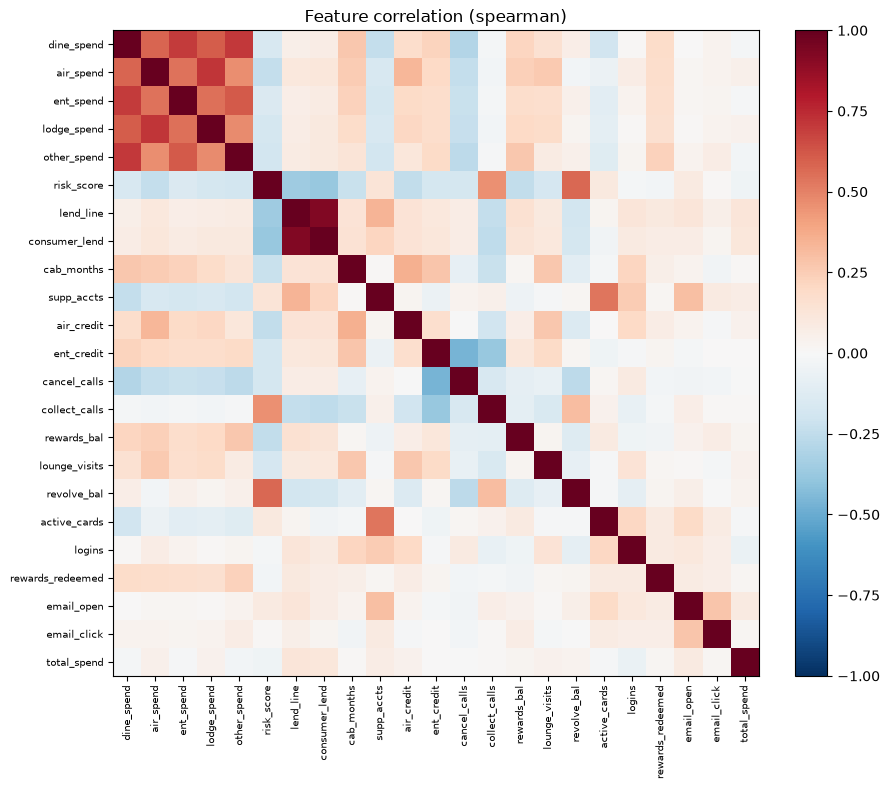

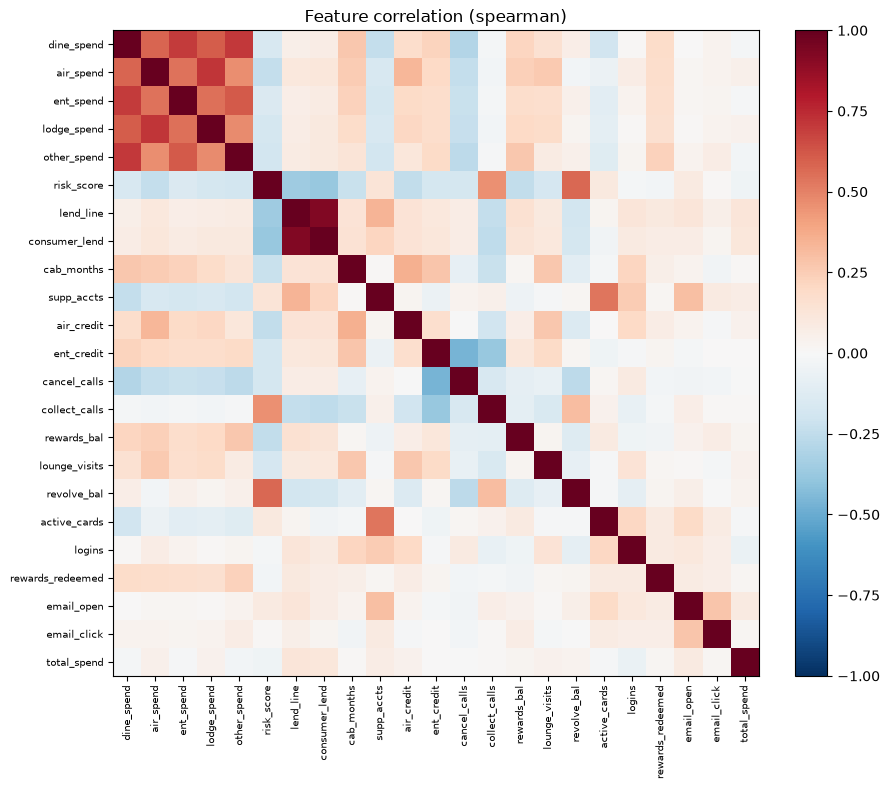

In [7]:
show(eda.plot_corr(), "Spearman feature-correlation heatmap")

## 4. Distributions — heavy tails (log1p) -> rank/log-transform before combining

**🧠 LLM:** - **Heavy-Tailed Distributions**: Each histogram shows a log-transformed distribution of various dollar-based features, indicating heavy-tailed characteristics where most values are low, but a few are extremely high.

- **Log Transformation**: The use of `log1p` (logarithm of 1 plus the value) helps in normalizing the data, making it easier to visualize and analyze the skewness and outliers.

- **Concentration of Low Values**: Most features have a large concentration of low values, suggesting that many cardmembers have low balances or spending in these categories.

- **Outliers and High Values**: The right tails of the distributions show significant outliers or high values, which could be key in identifying the most profitable cardmembers.

- **Feature Variability**: Different features show varying degrees of spread and concentration, indicating diverse spending and balance behaviors among cardmembers.

- **Implications for Scoring**: Understanding these distributions is crucial for designing a scoring framework that accurately captures profitability by considering both typical and atypical spending patterns.

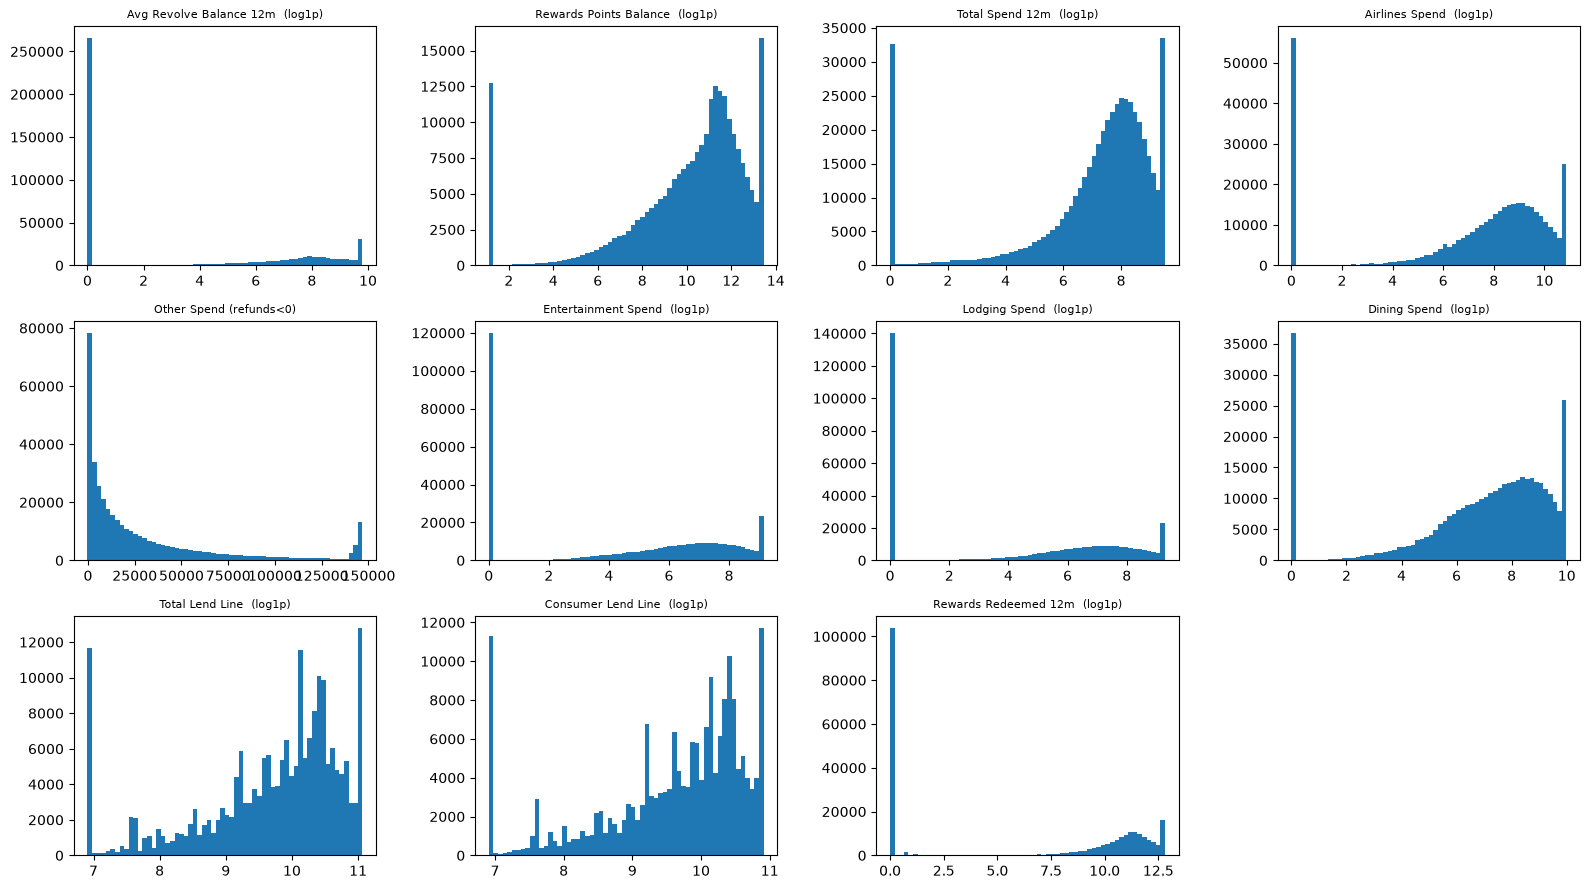

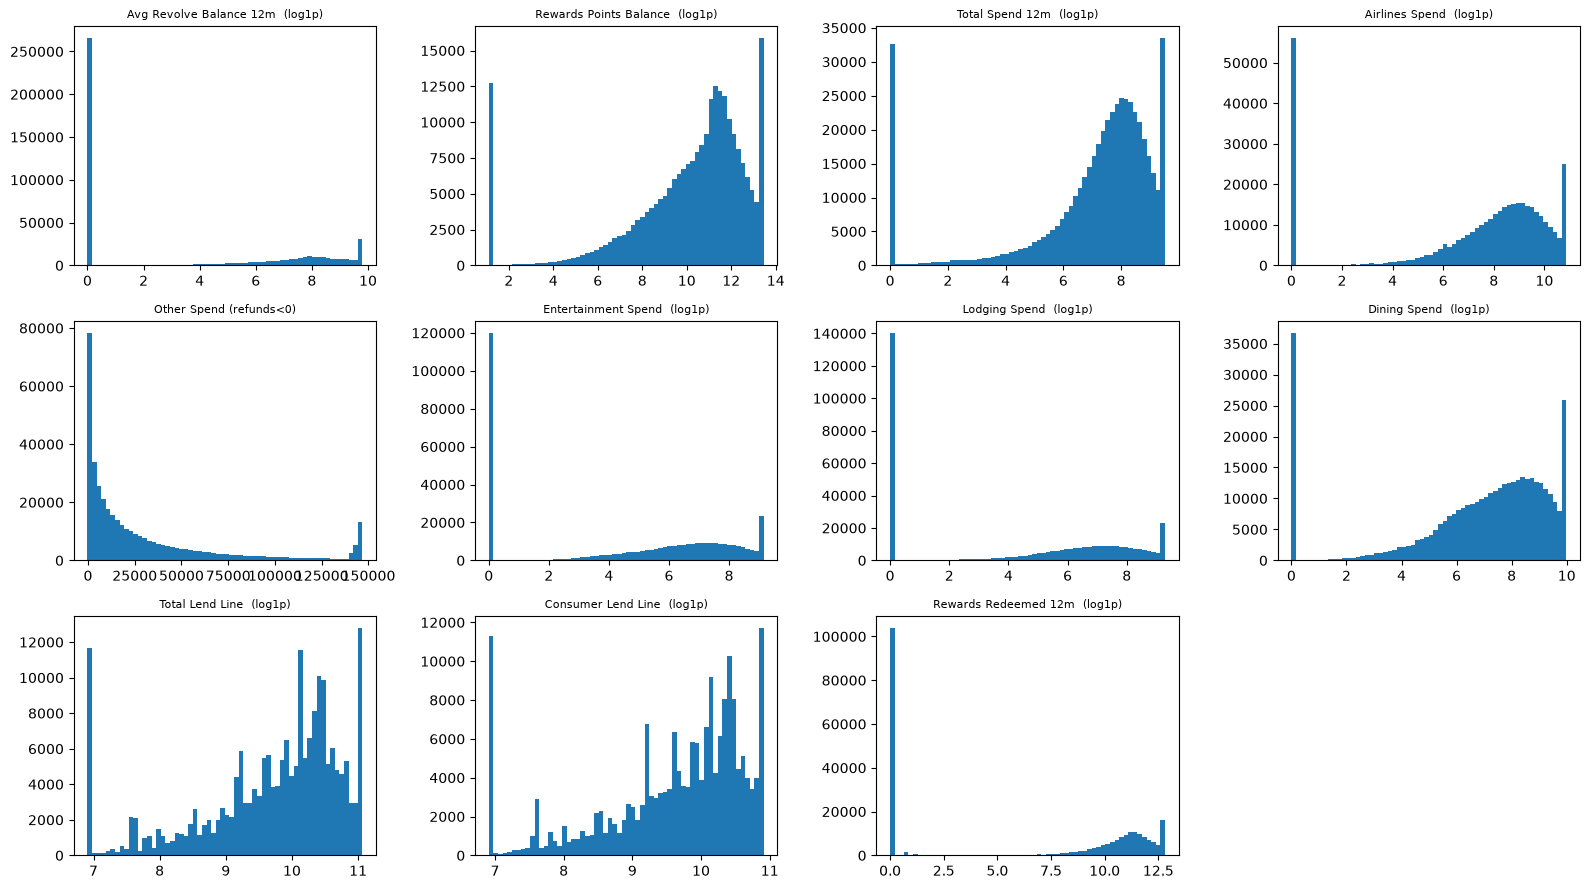

In [8]:
show(eda.plot_distributions(), "log1p distributions of the heavy-tailed dollar features")

## 5. Segments — transactor / revolver / lender archetypes

In [9]:
show(eda.segments(), "transactor / revolver / lender segment mean profiles")

,n,share%,total_spend,revolve_bal,risk_score,rewards_bal,cancel_calls
lender (has lend line),207746,41.5,3700.0,2618.0,0.0396,107592.0,0.187
transactor (charge-only),159584,31.9,3486.0,0.0,0.0056,164394.0,0.236
revolver (no lend line),132670,26.5,3065.0,5198.0,0.0591,109548.0,0.080


**🧠 LLM:** - **Segment Distribution**: The data shows three segments of cardmembers: lenders (41.5%), transactors (31.9%), and revolvers (26.5%). Understanding these proportions helps us identify which group contributes most to profitability.

- **Spending Patterns**: Lenders have the highest total spend ($3,700), followed closely by transactors ($3,486) and then revolvers ($3,065). This indicates that lenders and transactors may be more valuable to the issuer due to higher spending.

- **Revolving Balances**: Revolvers carry an average balance of $5,198, while transactors have none. This suggests that revolvers may incur more costs for the issuer due to interest, impacting their overall profitability.

- **Risk Scores**: Lenders have the lowest risk score (0.0396), indicating they are less likely to default, while revolvers have a higher risk score (0.0591). This is crucial for assessing the risk associated with each segment when calculating profitability.

- **Customer Engagement**: Transactors have the highest rate of cancel calls (23.6%), which may indicate dissatisfaction or a need for better engagement strategies. This could affect retention and profitability in the long run.

- **Implications for Scoring**: The insights from these profiles will help refine our revenue-minus-cost scoring framework by prioritizing segments that show higher profitability potential and lower risk, ultimately improving our overlap with the true top 20% of profitable cardmembers.

,n,share%,total_spend,revolve_bal,risk_score,rewards_bal,cancel_calls
lender (has lend line),207746,41.5,3700.0,2618.0,0.0396,107592.0,0.187
transactor (charge-only),159584,31.9,3486.0,0.0,0.0056,164394.0,0.236
revolver (no lend line),132670,26.5,3065.0,5198.0,0.0591,109548.0,0.080


## 6. Top-20% tail — the only region the metric scores. (try by='f7' too — the big-volume category)

In [10]:
show(eda.top_tail('f5'), "what distinguishes the top-20% by total_spend vs everyone else")

,code,top20%_by_total_spend,rest,ratio
variable,,,,
revolve_bal,f1,2613.79,2440.63,1.07
cancel_calls,f2,0.17,0.18,0.93
collect_calls,f3,0.09,0.11,0.75
rewards_bal,f4,155790.06,116538.22,1.34
total_spend,f5,9825.08,1874.75,5.24
air_spend,f6,13317.68,9144.63,1.46
other_spend,f7,37041.65,29143.19,1.27
ent_spend,f8,1903.33,1420.45,1.34
lodge_spend,f9,2279.75,1484.56,1.54


**🧠 LLM:** - **Total Spend**: The top 20% of cardmembers spend significantly more overall ($9,825.08) compared to the rest ($1,874.75), indicating they are high-value customers.
  
- **Rewards Balance**: The top group has a much higher rewards balance ($155,790.06) than the rest ($116,538.22), suggesting they are engaged and likely to redeem rewards, which can drive profitability.

- **Air and Other Spend**: Top spenders have higher air spend ($13,317.68) and other spend ($37,041.65), which may indicate a preference for travel and lifestyle purchases that can enhance issuer revenue.

- **Risk Score**: The top 20% have a lower risk score (0.02) compared to the rest (0.04), suggesting they are less likely to default, making them more attractive to the issuer.

- **Engagement Metrics**: The top group has fewer logins (27.70) compared to the rest (31.77), which may indicate that high spenders are less reliant on frequent account access, possibly due to their established loyalty.

- **Lounge Visits**: The top spenders visit lounges more frequently (0.56) than the rest (0.46), indicating higher engagement with premium services, which can enhance customer loyalty and profitability. 

These distinctions help refine our scoring framework by identifying key characteristics of high-value cardmembers, ensuring our profitability score accurately reflects true top performers.

,code,top20%_by_total_spend,rest,ratio
variable,,,,
revolve_bal,f1,2613.79,2440.63,1.07
cancel_calls,f2,0.17,0.18,0.93
collect_calls,f3,0.09,0.11,0.75
rewards_bal,f4,155790.06,116538.22,1.34
total_spend,f5,9825.08,1874.75,5.24
air_spend,f6,13317.68,9144.63,1.46
other_spend,f7,37041.65,29143.19,1.27
ent_spend,f8,1903.33,1420.45,1.34
lodge_spend,f9,2279.75,1484.56,1.54


In [11]:
show(eda.top_tail('f7'), "what distinguishes the top-20% by other_spend (the big-volume category)")

,code,top20%_by_other_spend,rest,ratio
variable,,,,
revolve_bal,f1,3202.32,2145.29,1.49
cancel_calls,f2,0.03,0.16,0.17
collect_calls,f3,0.00,0.00,0.53
rewards_bal,f4,223430.62,102353.15,2.18
total_spend,f5,4041.97,3402.44,1.19
air_spend,f6,22174.36,6996.44,3.17
other_spend,f7,99223.98,13720.77,7.23
ent_spend,f8,3994.76,905.04,4.41
lodge_spend,f9,3998.03,1065.16,3.75


**🧠 LLM:** - **Higher Revolving Balance**: The top 20% group has a significantly higher revolving balance ($3,202.32) compared to the rest ($2,145.29), indicating they may carry more debt, which can lead to higher interest revenue for the issuer.

- **Increased Other Spend**: The top 20% shows a staggering average of $99,223.98 in other spend, far exceeding the rest ($13,720.77). This suggests they are more engaged in spending beyond typical categories, which is crucial for profitability.

- **Greater Rewards Balance**: The rewards balance for the top 20% is much higher ($223,430.62) than that of the rest ($102,353.15), indicating they are likely to generate more revenue through rewards programs.

- **Significant Air and Dining Spend**: The top 20% spends considerably more on air ($22,174.36) and dining ($11,421.18) compared to the rest, which can enhance profitability through partnerships and premium offerings.

- **Low Cancel Calls**: The top 20% has a very low rate of cancel calls (0.03) compared to the rest (0.16), suggesting higher satisfaction and retention, which is vital for long-term profitability.

- **Overall Engagement**: Metrics like logins and lounge visits are similar between the two groups, indicating that engagement levels are consistent, but the top 20% is more profitable due to their spending patterns.

,code,top20%_by_other_spend,rest,ratio
variable,,,,
revolve_bal,f1,3202.32,2145.29,1.49
cancel_calls,f2,0.03,0.16,0.17
collect_calls,f3,0.00,0.00,0.53
rewards_bal,f4,223430.62,102353.15,2.18
total_spend,f5,4041.97,3402.44,1.19
air_spend,f6,22174.36,6996.44,3.17
other_spend,f7,99223.98,13720.77,7.23
ent_spend,f8,3994.76,905.04,4.41
lodge_spend,f9,3998.03,1065.16,3.75


## 7. Derived features (from f1–f23 only) — flags, ratios, rank transforms

In [12]:
feats = add_features(eda.df)
new = [c for c in feats.columns if c not in eda.df.columns]
show(feats[new].describe().T.round(3), "summary of the 21 engineered features (flags, ratios, rank transforms)")

,count,mean,std,min,25%,50%,75%,max
has_lend_line,500000.0,0.415,0.493,0.000,0.000,0.000,1.000,1.000
is_rewards_member,500000.0,0.486,0.500,0.000,0.000,0.000,1.000,1.000
has_spend_breakdown,500000.0,0.769,0.422,0.000,1.000,1.000,1.000,1.000
is_revolver,500000.0,0.681,0.466,0.000,0.000,1.000,1.000,1.000
redemption_intensity,242772.0,0.355,0.385,0.000,0.000,0.192,0.747,1.000
benefit_burden,480291.0,7.050,31.430,0.001,0.014,0.037,0.137,278.403
spend_diversity,500000.0,3.090,2.010,0.000,1.000,4.000,5.000,5.000
engagement,474994.0,13.989,13.928,0.000,4.000,9.000,19.000,58.000
revolve_to_lend,207746.0,0.444,1.608,0.000,0.000,0.000,0.209,17.968
net_spend,384302.0,48564.702,55945.419,-274.646,8618.521,26964.293,66771.818,240798.436


**🧠 LLM:** - **Feature Overview**: The table summarizes 21 engineered features used to assess cardmember profitability, including flags (e.g., `has_lend_line`, `is_rewards_member`) and various ratios (e.g., `spend_diversity`, `benefit_burden`).

- **Key Features**: 
  - `has_spend_breakdown` is present in 77% of members, indicating a strong engagement with spending details.
  - `is_rewards_member` shows nearly half of the members are part of the rewards program, which could correlate with higher profitability.

- **Profitability Indicators**: 
  - `net_spend` has a high mean value, suggesting that cardmembers generally spend significantly, which is crucial for profitability.
  - `benefit_burden` has a wide range, indicating some members may be utilizing benefits heavily, potentially impacting issuer costs.

- **Engagement Metrics**: 
  - The `engagement` feature shows a mean of nearly 14, suggesting that active members engage with multiple services, which may lead to higher profitability.

- **Ranking Features**: 
  - The `f1_rank` to `f21_rank` features are consistently around 0.5, indicating a balanced distribution across the ranks, which may help in identifying top performers effectively.

- **Importance for Scoring**: These features will be integral in calculating the revenue-minus-cost score, as they provide insights into member behavior and engagement, which are critical for predicting profitability and ensuring our top 20% aligns with the true top 20%.

,count,mean,std,min,25%,50%,75%,max
has_lend_line,500000.0,0.415,0.493,0.000,0.000,0.000,1.000,1.000
is_rewards_member,500000.0,0.486,0.500,0.000,0.000,0.000,1.000,1.000
has_spend_breakdown,500000.0,0.769,0.422,0.000,1.000,1.000,1.000,1.000
is_revolver,500000.0,0.681,0.466,0.000,0.000,1.000,1.000,1.000
redemption_intensity,242772.0,0.355,0.385,0.000,0.000,0.192,0.747,1.000
benefit_burden,480291.0,7.050,31.430,0.001,0.014,0.037,0.137,278.403
spend_diversity,500000.0,3.090,2.010,0.000,1.000,4.000,5.000,5.000
engagement,474994.0,13.989,13.928,0.000,4.000,9.000,19.000,58.000
revolve_to_lend,207746.0,0.444,1.608,0.000,0.000,0.000,0.209,17.968
net_spend,384302.0,48564.702,55945.419,-274.646,8618.521,26964.293,66771.818,240798.436


,variable,std,critic_w,entropy_w,equal_w
code,,,,,
f5,total_spend,0.287,0.0597,0.0698,0.0435
f12,logins,0.281,0.0556,0.0673,0.0435
f22,email_open,0.259,0.0523,0.0559,0.0435
f15,cab_months,0.279,0.0520,0.0615,0.0435
f16,ent_credit,0.278,0.0520,0.0672,0.0435
f1,revolve_bal,0.266,0.0514,0.0509,0.0435
f19,supp_accts,0.266,0.0507,0.0522,0.0435
f11,risk_score,0.283,0.0504,0.0628,0.0435
f7,other_spend,0.253,0.0448,0.0545,0.0435


**🧠 LLM:** - **Variable Importance**: The table ranks various features (like total spend, logins, and email open rates) based on three different weighting methods: CRITIC, entropy, and equal weights. This helps us understand which factors are most influential in determining profitability.

- **Top Features**: Total spend, logins, and email open rates have the highest scores across the CRITIC and entropy methods, indicating they are critical for predicting profitability. This suggests focusing on these metrics could improve our scoring framework.

- **Weighting Methods**: The CRITIC and entropy methods yield different importance scores compared to equal weights, highlighting that not all features contribute equally to profitability. This differentiation is essential for creating a more nuanced and effective profitability score.

- **Standard Deviation**: The standard deviation values show variability in each feature, which can inform us about the consistency of these metrics across cardmembers. Features with higher variability may provide more insight into profitability differences.

- **Actionable Insights**: By prioritizing features with higher weights, we can refine our profitability model to better identify the top 20% of cardmembers, ultimately improving our overlap with the true top 20%.

,variable,gini
f1,revolve_bal,0.803
f9,lodge_spend,0.755
f8,ent_spend,0.738
f21,rewards_redeemed,0.725
f4,rewards_bal,0.669
f6,air_spend,0.661
f10,dine_spend,0.648
f7,other_spend,0.619
f5,total_spend,0.554
f17,lend_line,0.407


**🧠 LLM:** - The Gini values indicate how well each feature (variable) distinguishes between high and low profitability cardmembers. Higher values suggest better discrimination.
- "Revolve balance" has the highest Gini score (0.803), meaning it is the most effective feature for identifying profitable cardmembers.
- Features like "lodge spend" and "entertainment spend" also show strong Gini scores (0.755 and 0.738), indicating they are important for our scoring framework.
- Lower Gini scores for features like "total spend" (0.554) and "consumer lend" (0.397) suggest they are less effective in differentiating profitability.
- This ranking helps prioritize which features to focus on when designing our revenue-minus-cost score, ensuring we capture the most relevant factors for profitability.

**🧠 LLM:** - **Segments Overview**: The chart shows three segments: lenders, revolvers, and transactors, each with distinct behaviors based on feature rankings.

- **Lenders**: They have high ranks in features like "revolve_bal" and "lend_line," indicating they often carry balances and have lending lines.

- **Revolvers**: This group shows moderate ranks across most features, with a notable low rank in "lend_line," suggesting they don't have lending lines.

- **Transactors**: They rank low in "revolve_bal" and "lend_line," indicating they pay off balances regularly and don't use lending lines.

- **Feature Importance**: Features like "risk_score" and "consumer_lend_line" show significant variation across segments, highlighting their importance in differentiating customer behavior.

- **Implications for Profitability**: Understanding these segment behaviors can help tailor strategies to maximize profitability by focusing on high-value features for each group.

**🧠 LLM:** - **Equality Line**: The dashed line represents perfect equality, where each member contributes equally to the value.

- **Total Spend (G=0.55)**: This curve is closest to the equality line, indicating a relatively even distribution of spending among members.

- **Other Spend (G=0.62)**: This curve shows more concentration than total spend, meaning fewer members account for a larger share of this spending.

- **Revolve Balance (G=0.80)**: This curve is furthest from the equality line, indicating a high concentration where a small number of members hold most of the balance.

- **Rewards Balance (G=0.67)**: This curve shows moderate concentration, with rewards balances being more unevenly distributed than total spend but less than revolve balance.

- **Gini Coefficients**: Higher Gini values indicate greater inequality in distribution, with revolve balance being the most concentrated. This matters for identifying key contributors to profitability.

**🧠 LLM:** - **High Positive Influence**: The top 20% is significantly defined by high "other_spend," "ent_spend," and "dine_spend," indicating these spending categories are key differentiators.
  
- **Moderate Positive Influence**: Categories like "lodge_spend," "air_spend," and "rewards_redeemed" also contribute positively, suggesting travel and rewards activities are important.

- **Neutral Influence**: Factors such as "total_spend" and "consumer_lend" have minimal impact, indicating they are less distinctive for the top 20%.

- **Negative Influence**: "Active_cards," "supp_accts," and "collect_calls" negatively define the top 20%, suggesting these are less common or less beneficial behaviors.

- **Risk Indicators**: "Risk_score" and "cancel_calls" are negatively associated, implying lower risk and fewer cancellations are characteristics of the top 20%.

**🧠 LLM:** [explain failed: TimeoutError: The read operation timed out]

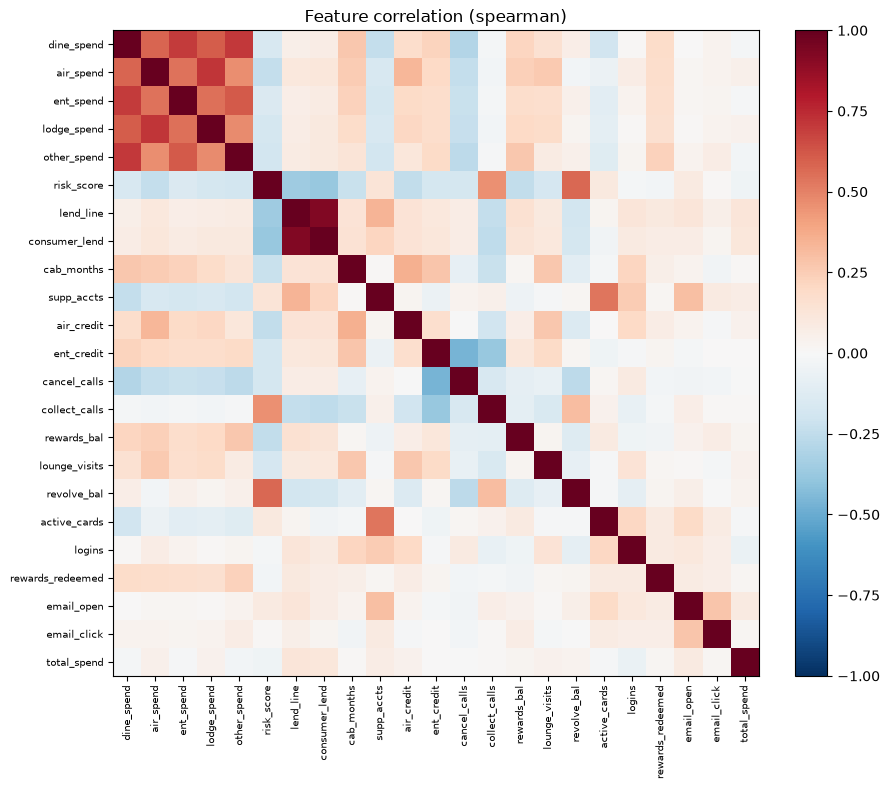

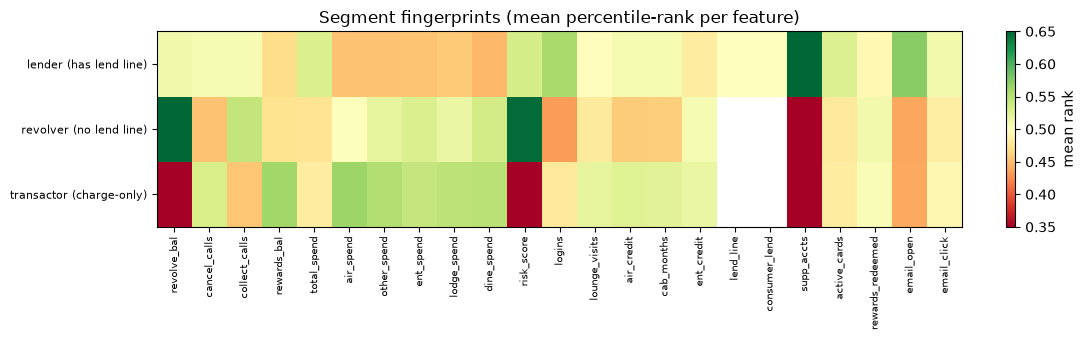

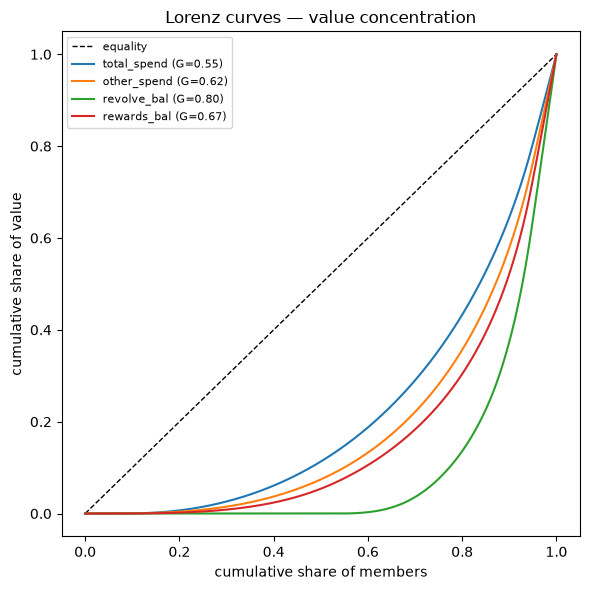

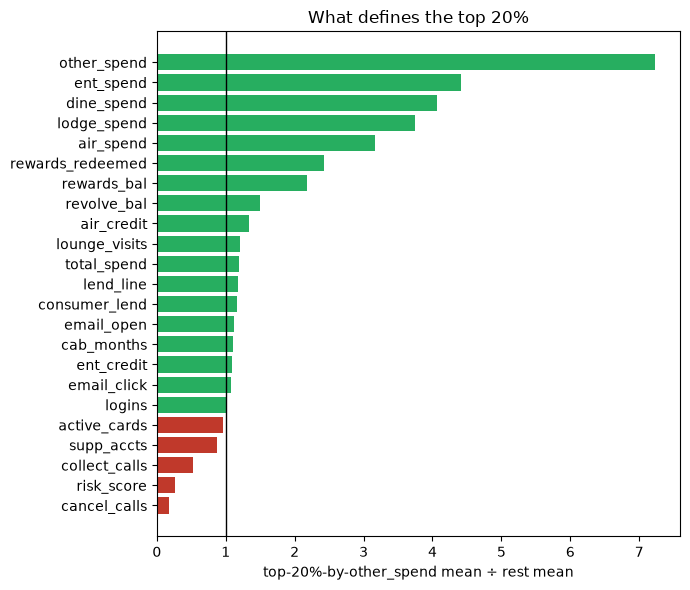

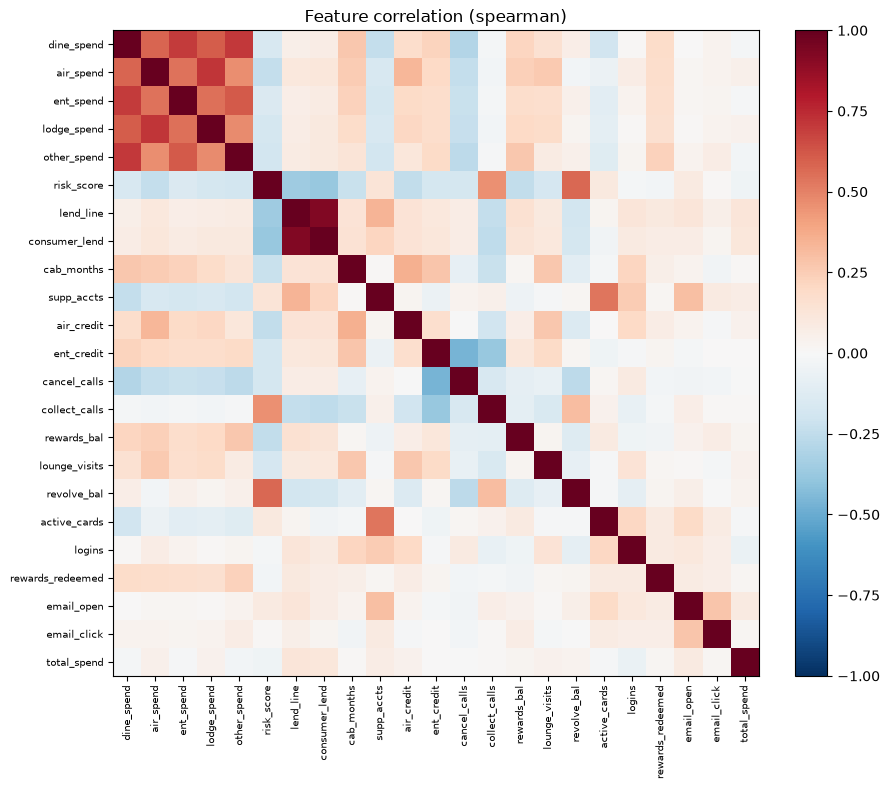

In [13]:
# --- 8. Research-backed analyses + LLM explanations ---
show(eda.weights(), "objective CRITIC / entropy / equal feature weights")
show(eda.concentration(), "Gini value-concentration per feature")
show(eda.plot_segment_profiles(), "segment fingerprint heatmap (mean percentile-rank per feature)")
show(eda.plot_lorenz(), "Lorenz value-concentration curves")
show(eda.plot_top_tail('f7'), "diverging bars: what defines the top-20% by other_spend")
show(eda.plot_corr('spearman'), "Spearman correlation heatmap")